# Assignment 1: Linear regression implementation

This notebook follows a linear-regression workflow: inspect and plot the data, compare NumPy and scikit-learn least-squares fits, implement gradient descent, examine convergence under different learning rates and iteration counts, and compare test RMS across model feature sets. The train/test split is deterministic (`random_state=42`). Test/train ratios are 0.25, 0.5, and 1.0.

**Metric:** RMS = square root of the mean squared prediction error on held-out rows. Coefficients are reported as `y = X @ w + b`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42


## Data and model definitions

Used Toyota Corolla prices: model (a) uses year, model (b) adds mileage, and model (c) adds mileage squared. The squared term lets the relationship with mileage curve. The data cell creates that term and removes incomplete rows so the same 287 listings are available to all three models.


In [2]:
# Read the included CSV. All required data files are stored beside this notebook.
df = pd.read_csv("cars-cleaned.csv")
# Remove an exported row index column, if present.
df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]

# Add polynomial terms used by the requested models.
df["mileage_sq"] = df["mileage"] ** 2
target = "price"
feature_sets = {
    "a": ['year'],
    "b": ['year', 'mileage'],
    "c": ['year', 'mileage', 'mileage_sq'],
}
required = sorted({target, *[feature for features in feature_sets.values() for feature in features]})
df = df.dropna(subset=required).reset_index(drop=True)
print(f"Rows used: {len(df)}")
display(df.head())
display(df[required].describe().round(2))


Rows used: 287


,vehicle,year,mileage,price,mileage_sq
0,2017 Toyota Corolla SE,2017,75540,15946,5706291600
1,2019 Toyota Corolla LE,2019,57206,17378,3272526436
2,2020 Toyota Corolla LE,2020,20182,20580,407313124
3,2020 Toyota Corolla LE,2020,50398,19000,2539958404
4,2019 Toyota Corolla LE,2019,60156,18990,3618744336


,mileage,mileage_sq,price,year
count,287.00,2.870000e+02,287.00,287.00
mean,54648.78,4.474940e+09,18301.64,2017.21
std,38647.84,6.884718e+09,4676.20,3.44
min,10.00,1.000000e+02,3800.00,2003.00
25%,27628.00,7.633280e+08,15963.50,2016.00
50%,47633.00,2.268903e+09,18520.00,2018.00
75%,68287.50,4.663228e+09,21887.00,2020.00
max,230133.00,5.296120e+10,27811.00,2022.00


## Visualize the data

Each scatter plot shows the target against one original predictor. The red line on the first plot is model (a) fitted to all rows for illustration; the later RMS table uses separate training and test rows.


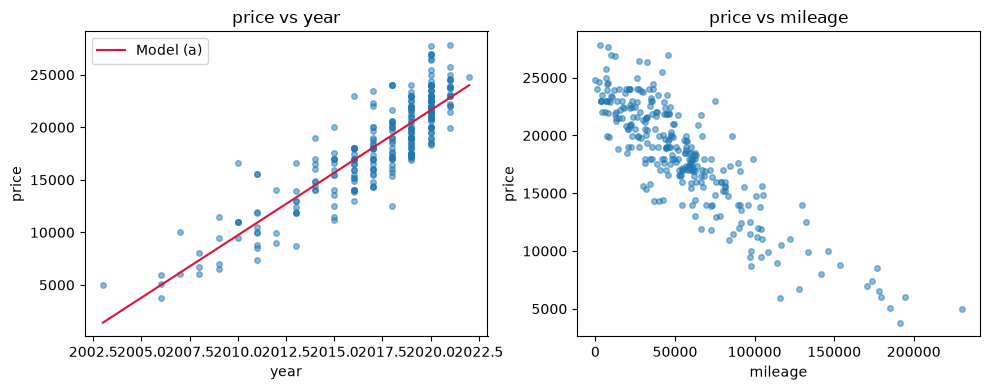

In [3]:
# Show how the target varies with each original predictor.
base_features = ['year', 'mileage']
fig, axes = plt.subplots(1, len(base_features), figsize=(5 * len(base_features), 4))
for ax, feature in zip(axes, base_features):
    ax.scatter(df[feature], df[target], alpha=0.5, s=16)
    if feature == feature_sets["a"][0]:
        # Show the full-data one-feature fit as a visual reference.
        fitted_line = LinearRegression().fit(df[[feature]].to_numpy(dtype=float), df[target])
        x_line = np.linspace(df[feature].min(), df[feature].max(), 200).reshape(-1, 1)
        ax.plot(x_line[:, 0], fitted_line.predict(x_line), color="crimson", label="Model (a)")
        ax.legend()
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {feature}")
plt.tight_layout()
plt.show()


## Fit coefficients and compare implementations

The first fit uses all available rows to report each model's coefficients. Features are standardized inside the least-squares calculation to improve numerical stability, then coefficients are converted back to the original units. The next cell compares all three models with scikit-learn. Full-data fits describe the data; test RMS below comes only from models trained on training rows.


In [4]:
def fit_least_squares(X, y):
    """Fit stable least squares and return coefficients in the original units."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    # Center and scale predictors before solving to limit rounding errors.
    centers = X.mean(axis=0)
    scales = X.std(axis=0)
    scales = np.where(scales == 0, 1.0, scales)
    design = np.column_stack([(X - centers) / scales, np.ones(len(y))])
    theta, *_ = np.linalg.lstsq(design, y, rcond=None)
    # Convert coefficients back to the CSV column units for reporting.
    weights = theta[:-1] / scales
    bias = float(theta[-1] - centers @ weights)
    return weights, bias

full_fits = {}
for name, features in feature_sets.items():
    X = df[features].to_numpy(dtype=float)
    y = df[target].to_numpy(dtype=float)
    w, bias = fit_least_squares(X, y)
    full_fits[name] = (w, bias)
    print(f"Model {name}: features={features}")
    print(f"  w={w}; b={bias:.8f}")
    print(f"  equation: {target} = " + " + ".join(
        [f"({coef:.8g} * {feature})" for coef, feature in zip(w, features)] + [f"({bias:.8g})"]
    ))
    print()


Model a: features=['year']
  w=[1188.88797395]; b=-2379929.80439249
  equation: price = (1188.888 * year) + (-2379929.8)

Model b: features=['year', 'mileage']
  w=[ 6.69510136e+02 -5.65570535e-02]; b=-1329147.16067264
  equation: price = (669.51014 * year) + (-0.056557054 * mileage) + (-1329147.2)

Model c: features=['year', 'mileage', 'mileage_sq']
  w=[ 6.93328961e+02 -8.96564159e-02  2.10047497e-07]; b=-1376325.73677672
  equation: price = (693.32896 * year) + (-0.089656416 * mileage) + (2.100475e-07 * mileage_sq) + (-1376325.7)



## One-feature cost surface

The surface shows training mean squared error (MSE) for different values of the slope `w` and intercept `b` in model (a). Its low point corresponds to the best fit on the available rows. The held-out RMS later in the notebook measures a different thing: prediction error on rows excluded from fitting.


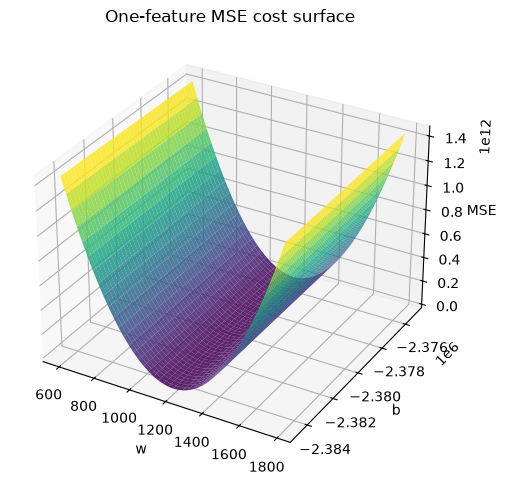

In [5]:
# Experiment: visualize the MSE surface for the first, one-feature model.
# The grid is centered on the least-squares solution so the minimum is visible.
x_cost = df[feature_sets["a"][0]].to_numpy(dtype=float)
y_cost = df[target].to_numpy(dtype=float)
w_star, b_star = fit_least_squares(x_cost.reshape(-1, 1), y_cost)
w_grid = np.linspace(w_star[0] - max(abs(w_star[0]) * 0.5, 1.0), w_star[0] + max(abs(w_star[0]) * 0.5, 1.0), 45)
b_grid = np.linspace(b_star - max(np.std(y_cost), 1.0), b_star + max(np.std(y_cost), 1.0), 45)
W, B = np.meshgrid(w_grid, b_grid)
Z = np.mean((W[..., None] * x_cost + B[..., None] - y_cost) ** 2, axis=2)
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(W, B, Z, cmap="viridis", alpha=0.85)
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("MSE")
ax.set_title("One-feature MSE cost surface")
plt.tight_layout()
plt.show()


In [6]:
# Compare two independent ordinary least-squares implementations for every model.
for name, features in feature_sets.items():
    X = df[features].to_numpy(dtype=float)
    y = df[target].to_numpy(dtype=float)
    w, bias = full_fits[name]
    reference = make_pipeline(StandardScaler(), LinearRegression()).fit(X, y)
    scaler = reference.named_steps["standardscaler"]
    regressor = reference.named_steps["linearregression"]
    reference_w = regressor.coef_ / scaler.scale_
    reference_b = regressor.intercept_ - scaler.mean_ @ reference_w
    predictions = X @ w + bias
    print(f"Model {name}: maximum weight difference = {np.max(np.abs(w - reference_w)):.3g}")
    print(f"  bias difference = {abs(bias - reference_b):.3g}")
    print(f"  training RMS = {np.sqrt(np.mean((y - predictions) ** 2)):.3f}")


Model a: maximum weight difference = 3.82e-11
  bias difference = 7.68e-08
  training RMS = 2267.180
Model b: maximum weight difference = 6.82e-13
  bias difference = 1.4e-09
  training RMS = 1885.921
Model c: maximum weight difference = 3.41e-13
  bias difference = 6.98e-10
  training RMS = 1811.266


## Held-out RMS at different test/train ratios

For ratio `r`, the test fraction is `r / (1 + r)`: a ratio of 0.25 gives 80% training and 20% testing, while 1.0 gives a 50/50 split. All feature sets use the same seeded split for a given ratio. The pipeline learns feature scaling from training rows only, fits the regression, predicts held-out rows, and computes RMS. Lower test RMS means better predictions on that split.


In [7]:
rows = []
for ratio in (0.25, 0.5, 1.0):
    # Convert the requested test/train ratio to a fraction of all rows.
    test_fraction = ratio / (1.0 + ratio)
    for name, features in feature_sets.items():
        X = df[features].to_numpy(dtype=float)
        y = df[target].to_numpy(dtype=float)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_fraction, random_state=RANDOM_STATE
        )
        # StandardScaler is fitted only on X_train inside this pipeline.
        model = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
        predictions = model.predict(X_test)
        rows.append({
            "model": name,
            "features": ", ".join(features),
            "test/train ratio": ratio,
            "train rows": len(y_train),
            "test rows": len(y_test),
            "test RMS": np.sqrt(np.mean((y_test - predictions) ** 2)),
        })
rms_results = pd.DataFrame(rows)
display(rms_results.pivot(index="test/train ratio", columns="model", values="test RMS").round(3))
display(rms_results.round(3))


model,a,b,c
test/train ratio,,,
0.25,2197.024,1672.891,1590.280
0.50,2252.005,1889.004,1723.342
1.00,2168.775,1814.382,1685.908


,model,features,test/train ratio,train rows,test rows,test RMS
0,a,year,0.25,229,58,2197.024
1,b,"year, mileage",0.25,229,58,1672.891
2,c,"year, mileage, mileage_sq",0.25,229,58,1590.280
3,a,year,0.50,191,96,2252.005
4,b,"year, mileage",0.50,191,96,1889.004
5,c,"year, mileage, mileage_sq",0.50,191,96,1723.342
6,a,year,1.00,143,144,2168.775
7,b,"year, mileage",1.00,143,144,1814.382
8,c,"year, mileage, mileage_sq",1.00,143,144,1685.908


## Polynomial degree experiment

This separate experiment fits degrees 1 through 5 using one predictor. The scaler is fitted on training rows before making polynomial features, which keeps large powers numerically manageable. Compare train and test RMS: a lower training error alone does not guarantee a lower test error. This experiment does not replace the three required feature-set comparisons.


,degree,train RMS,test RMS
0,1,2442.892,2163.949
1,2,2438.690,2120.927
2,3,2438.665,2115.391
3,4,2435.666,2347.205
4,5,2435.544,2188.400


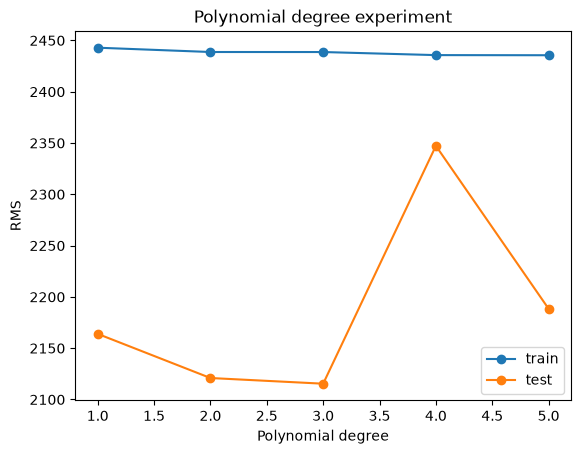

In [8]:
# Experiment: compare polynomial degree on one predictor.
# Reuse the largest test fraction (test/train = 1) for this degree sweep.
x_degree = df[["mileage"]].to_numpy(dtype=float)
y_degree = df[target].to_numpy(dtype=float)
X_train, X_test, y_train, y_test = train_test_split(
    x_degree, y_degree, test_size=0.5, random_state=RANDOM_STATE
)
degree_rows = []
for degree in range(1, 6):
    # Scale using training data before expanding powers to avoid huge values.
    model = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    ).fit(X_train, y_train)
    degree_rows.append({
        "degree": degree,
        "train RMS": np.sqrt(np.mean((y_train - model.predict(X_train)) ** 2)),
        "test RMS": np.sqrt(np.mean((y_test - model.predict(X_test)) ** 2)),
    })
degree_results = pd.DataFrame(degree_rows)
display(degree_results.round(3))
plt.plot(degree_results["degree"], degree_results["train RMS"], "o-", label="train")
plt.plot(degree_results["degree"], degree_results["test RMS"], "o-", label="test")
plt.xlabel("Polynomial degree")
plt.ylabel("RMS")
plt.title("Polynomial degree experiment")
plt.legend()
plt.show()


## Gradient descent and feature scaling

Gradient descent uses standardized input features and target values. We compare learning rates, iteration budgets, and zero versus nonzero initial weights. The update minimizes half the mean squared error; the displayed history reports mean squared error, which has the same minimum.

Each row reports the cost after the stated number of updates and its RMS after converting predictions back to the target's original units. These are full-data optimization diagnostics, not held-out test scores; use the preceding test RMS table to compare predictive performance.


,initial weights,learning rate,iterations,final scaled MSE,full-data RMS (original units)
0,zero,0.01,100,0.20036,2089.46665
1,zero,0.01,1000,0.15945,1863.99694
2,zero,0.10,100,0.15940,1863.72979
3,zero,0.10,1000,0.15055,1811.26637
4,zero,0.50,100,0.15059,1811.49804
5,zero,0.50,1000,0.15055,1811.26605
6,0.1,0.01,100,0.19008,2035.19302
7,0.1,0.01,1000,0.15979,1866.00385
8,0.1,0.10,100,0.15975,1865.77257
9,0.1,0.10,1000,0.15055,1811.26639


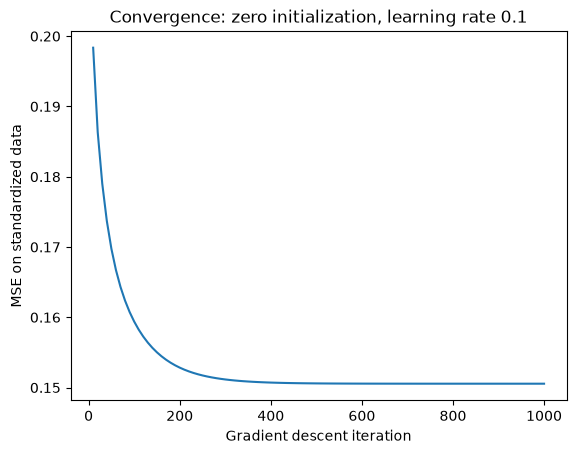

In [9]:
def gradient_descent(X, y, learning_rate, iterations, initial_w=None, initial_b=0.0):
    """Batch gradient descent for half-MSE cost on standardized data."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).reshape(-1)
    m, n = X.shape
    w = np.zeros(n) if initial_w is None else np.asarray(initial_w, dtype=float).copy()
    bias = float(initial_b)
    history = []
    for step in range(iterations):
        error = X @ w + bias - y
        dw = (X.T @ error) / m
        db = error.mean()
        w -= learning_rate * dw
        bias -= learning_rate * db
        if (step + 1) % max(1, iterations // 100) == 0 or step == iterations - 1:
            history.append(float(np.mean((X @ w + bias - y) ** 2)))
    return w, bias, history

# Demonstrate sensitivity to initialization, step size, and iteration budget.
features = feature_sets["c"]
X = df[features].to_numpy(dtype=float)
y = df[target].to_numpy(dtype=float)
x_scaler = StandardScaler().fit(X)
y_scaler = StandardScaler().fit(y.reshape(-1, 1))
X_scaled = x_scaler.transform(X)
y_scaled = y_scaler.transform(y.reshape(-1, 1)).ravel()
experiment_rows = []
convergence_history = None
for initialization, initial_w in (
    ("zero", np.zeros(X_scaled.shape[1])),
    ("0.1", np.full(X_scaled.shape[1], 0.1)),
):
    for rate in (0.01, 0.1, 0.5):
        for iterations in (100, 1000):
            w_gd, b_gd, history = gradient_descent(
                X_scaled, y_scaled, learning_rate=rate,
                iterations=iterations, initial_w=initial_w,
            )
            if initialization == "zero" and rate == 0.1 and iterations == 1000:
                convergence_history = history
            pred_scaled = X_scaled @ w_gd + b_gd
            pred = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
            experiment_rows.append({
                "initial weights": initialization,
                "learning rate": rate,
                "iterations": iterations,
                "final scaled MSE": history[-1],
                "full-data RMS (original units)": np.sqrt(np.mean((y - pred) ** 2)),
            })
display(pd.DataFrame(experiment_rows).round(5))
# Plot one run to show the cost decreasing during gradient descent.
steps = np.arange(10, 1001, 10)
plt.plot(steps, convergence_history)
plt.xlabel("Gradient descent iteration")
plt.ylabel("MSE on standardized data")
plt.title("Convergence: zero initialization, learning rate 0.1")
plt.show()


## Conclusion

Adding mileage to model (a) substantially lowers test RMS at every split ratio. Adding squared mileage lowers it further, indicating a curved mileage effect in this sample. Model (c) has the lowest test RMS across the three ratios. Multivariable and nonlinear terms capture age and depreciation patterns that year alone misses.

The fitted coefficients describe association in this dataset; they do not establish causal effects. Test RMS is measured on held-out rows and is the appropriate basis for comparing these models.

At a test/train ratio of 0.25, model (c) has RMS 1590.280 versus 2197.024 for year alone, a reduction of about 607 price units. The gain is visible at the other ratios too, although its size changes with the split.

The coefficient table below describes a fit to all available rows; the RMS table comes from separate fits using only the training part of each split. A squared term means the effect of its base predictor can vary with its value, so its two coefficients should be interpreted together.

### Full-data fitted coefficients

| Model | Predictors | Weights w (in listed order) | Bias b |
|---|---|---|---|
| a | year | 1188.89 | -2.37993e+06 |
| b | year, mileage | 669.51, -0.0565571 | -1.32915e+06 |
| c | year, mileage, mileage_sq | 693.329, -0.0896564, 2.10047e-07 | -1.37633e+06 |

### Held-out test RMS

| Model | Test/train ratio | Train n | Test n | RMS |
|---|---:|---:|---:|---:|
| a | 0.25 | 229 | 58 | 2197.024 |
| a | 0.5 | 191 | 96 | 2252.005 |
| a | 1 | 143 | 144 | 2168.775 |
| b | 0.25 | 229 | 58 | 1672.891 |
| b | 0.5 | 191 | 96 | 1889.004 |
| b | 1 | 143 | 144 | 1814.382 |
| c | 0.25 | 229 | 58 | 1590.280 |
| c | 0.5 | 191 | 96 | 1723.342 |
| c | 1 | 143 | 144 | 1685.908 |